In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# 1. Load Data
df_sales = pd.read_csv('E-commerece sales data 2024.csv')
df_customer = pd.read_csv('customer_details.csv')
df_product = pd.read_csv('product_details.csv')

In [8]:
# 2. Cek Data Kosong & Tipe Data
#data sales dari E-commerece sales data 2024.csv
print(df_sales.info())
print(df_sales.isnull().sum())

#data customer dari customer_details.csv
print(df_customer.info())
print(df_customer.isnull().sum())
#data product dari product_details.csv
print(df_product.info())
print(df_product.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3294 entries, 0 to 3293
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user id           2999 non-null   float64
 1   product id        2999 non-null   object 
 2   Interaction type  2871 non-null   object 
 3   Time stamp        2999 non-null   object 
 4   Unnamed: 4        0 non-null      float64
dtypes: float64(2), object(3)
memory usage: 128.8+ KB
None
user id              295
product id           295
Interaction type     423
Time stamp           295
Unnamed: 4          3294
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   obje

In [9]:
# 3. Pembersihan data 

#penghapusan duplicat
df_product=df_product.drop_duplicates()

#penghapusan data kosong
df_product = df_product.dropna(subset=['Selling Price'])
df_product = df_product.dropna(axis=1, how='all')

#merapikan format teks
df_product['Category'] = df_product['Category'].str.lower().str.strip()

#menghilangkan simbol dollar dan koma
df_product['Selling Price'] = df_product['Selling Price'].replace('[\$,]', '', regex=True)


df_product['Selling Price'] = df_product['Selling Price'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)
# membersihkan kolom harga
df_product['Selling Price'] = df_product['Selling Price'].astype(float)


# pembersihan data sales

df_sales = df_sales.loc[:, ~df_sales.columns.str.contains('^Unnamed')]

df_sales['Time stamp'] = pd.to_datetime(df_sales['Time stamp'], errors='coerce')

df_sales = df_sales.dropna(subset=['user id', 'product id'])
#pembersihan data customer

df_customer = df_customer[df_customer['Age'] > 0]
df_customer = df_customer[df_customer['Purchase Amount (USD)'] >= 0]
df_customer = df_customer.drop_duplicates(subset=['Customer ID'], keep='first')


In [10]:
print("setelah pembersihan", len (df_product)) 
display(df_product.head(5), df_customer.head(5),df_sales.head(5))

setelah pembersihan 9895


,Uniqe Id,Product Name,Category,Upc Ean Code,Selling Price,Model Number,About Product,Product Specification,Technical Details,Shipping Weight,Product Dimensions,Image,Variants,Product Url,Is Amazon Seller
0,4c69b61db1fc16e7013b43fc926e502d,"DB Longboards CoreFlex Crossbow 41"" Bamboo Fib...",sports & outdoors | outdoor recreation | skate...,NaN,237.68,NaN,Make sure this fits by entering your model num...,Shipping Weight: 10.7 pounds (View shipping ra...,NaN,10.7 pounds,NaN,https://images-na.ssl-images-amazon.com/images...,https://www.amazon.com/DB-Longboards-CoreFlex-...,https://www.amazon.com/DB-Longboards-CoreFlex-...,Y
1,66d49bbed043f5be260fa9f7fbff5957,"Electronic Snap Circuits Mini Kits Classpack, ...",toys & games | learning & education | science ...,NaN,99.95,55324,Make sure this fits by entering your model num...,Product Dimensions: 14.7 x 11.1 x 10.2...,The snap circuits mini kits classpack provides...,4 pounds,14.7 x 11.1 x 10.2 inches 4.06 pounds,https://images-na.ssl-images-amazon.com/images...,NaN,https://www.amazon.com/Electronic-Circuits-Cla...,Y
2,2c55cae269aebf53838484b0d7dd931a,3Doodler Create Flexy 3D Printing Filament Ref...,toys & games | arts & crafts | craft kits,NaN,34.99,NaN,Make sure this fits by entering your model num...,ProductDimensions:10.3x3.4x0.8inches|ItemWeigh...,show up to 2 reviews by default No longer are ...,12.8 ounces,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,https://www.amazon.com/3Doodler-Plastic-Innova...,Y
3,18018b6bc416dab347b1b7db79994afa,Guillow Airplane Design Studio with Travel Cas...,toys & games | hobbies | models & model kits |...,NaN,28.91,142,Make 8 different Planes at one time. | Experim...,ProductDimensions:3.5x6.2x13inches|ItemWeight:...,Go to your orders and start the return Select ...,13.4 ounces,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,https://www.amazon.com/Guillow-Airplane-Design...,Y
4,e04b990e95bf73bbe6a3fa09785d7cd0,Woodstock- Collage 500 pc Puzzle,toys & games | puzzles | jigsaw puzzles,NaN,17.49,62151,Make sure this fits by entering your model num...,ProductDimensions:1.9x8x10inches|ItemWeight:13...,show up to 2 reviews by default 100% Officiall...,13.4 ounces,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,https://www.amazon.com/Woodstock-Collage-500-p...,Y


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


,user id,product id,Interaction type,Time stamp
0,1.0,4c69b61db1fc16e7013b43fc926e502d,purchase,2023-10-10 08:00:00
1,2.0,66d49bbed043f5be260fa9f7fbff5957,view,2023-11-10 08:00:00
2,3.0,2c55cae269aebf53838484b0d7dd931a,like,2023-12-10 08:00:00
3,4.0,18018b6bc416dab347b1b7db79994afa,view,2023-10-13 08:00:00
4,5.0,e04b990e95bf73bbe6a3fa09785d7cd0,like,2023-10-14 08:00:00


In [11]:
#penggabungan ketiga data
df_master =pd.merge(df_sales, df_customer, left_on='user id',right_on='Customer ID', how='left')
df_master = pd.merge(df_master, df_product, left_on='product id', right_on='Uniqe Id', how='left')
df_master= df_master.drop(columns=['Customer ID', 'Uniqe Id'])

display(df_master.head(5))


,user id,product id,Interaction type,Time stamp,Age,Gender,Item Purchased,Category_x,Purchase Amount (USD),Location,...,Model Number,About Product,Product Specification,Technical Details,Shipping Weight,Product Dimensions,Image,Variants,Product Url,Is Amazon Seller
0,1.0,4c69b61db1fc16e7013b43fc926e502d,purchase,2023-10-10 08:00:00,55,Male,Blouse,Clothing,53,Kentucky,...,NaN,Make sure this fits by entering your model num...,Shipping Weight: 10.7 pounds (View shipping ra...,NaN,10.7 pounds,NaN,https://images-na.ssl-images-amazon.com/images...,https://www.amazon.com/DB-Longboards-CoreFlex-...,https://www.amazon.com/DB-Longboards-CoreFlex-...,Y
1,2.0,66d49bbed043f5be260fa9f7fbff5957,view,2023-11-10 08:00:00,19,Male,Sweater,Clothing,64,Maine,...,55324,Make sure this fits by entering your model num...,Product Dimensions: 14.7 x 11.1 x 10.2...,The snap circuits mini kits classpack provides...,4 pounds,14.7 x 11.1 x 10.2 inches 4.06 pounds,https://images-na.ssl-images-amazon.com/images...,NaN,https://www.amazon.com/Electronic-Circuits-Cla...,Y
2,3.0,2c55cae269aebf53838484b0d7dd931a,like,2023-12-10 08:00:00,50,Male,Jeans,Clothing,73,Massachusetts,...,NaN,Make sure this fits by entering your model num...,ProductDimensions:10.3x3.4x0.8inches|ItemWeigh...,show up to 2 reviews by default No longer are ...,12.8 ounces,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,https://www.amazon.com/3Doodler-Plastic-Innova...,Y
3,4.0,18018b6bc416dab347b1b7db79994afa,view,2023-10-13 08:00:00,21,Male,Sandals,Footwear,90,Rhode Island,...,142,Make 8 different Planes at one time. | Experim...,ProductDimensions:3.5x6.2x13inches|ItemWeight:...,Go to your orders and start the return Select ...,13.4 ounces,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,https://www.amazon.com/Guillow-Airplane-Design...,Y
4,5.0,e04b990e95bf73bbe6a3fa09785d7cd0,like,2023-10-14 08:00:00,45,Male,Blouse,Clothing,49,Oregon,...,62151,Make sure this fits by entering your model num...,ProductDimensions:1.9x8x10inches|ItemWeight:13...,show up to 2 reviews by default 100% Officiall...,13.4 ounces,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,https://www.amazon.com/Woodstock-Collage-500-p...,Y


In [17]:
df_master = df_master[df_master['Interaction type'] == 'purchase'].copy()

# mengubah format datetime ke bulan
df_master['Time stamp'] = pd.to_datetime(df_master['Time stamp'], format='%d/%m/%Y %H:%M', errors='coerce')
df_master = df_master.dropna(subset=['Time stamp'])

# pembuatan kolom baru
df_master['Month-Year'] =df_master['Time stamp'].dt.to_period('M')

In [19]:
# menghitung jumlah penjualan perbulan & mengurutkannya
monthly_sales = df_master.groupby('Month-Year').size().reset_index(name='Total Sales')
monthly_sales = monthly_sales.sort_values('Month-Year')
monthly_sales['Month-Year'] = monthly_sales['Month-Year'].astype(str)

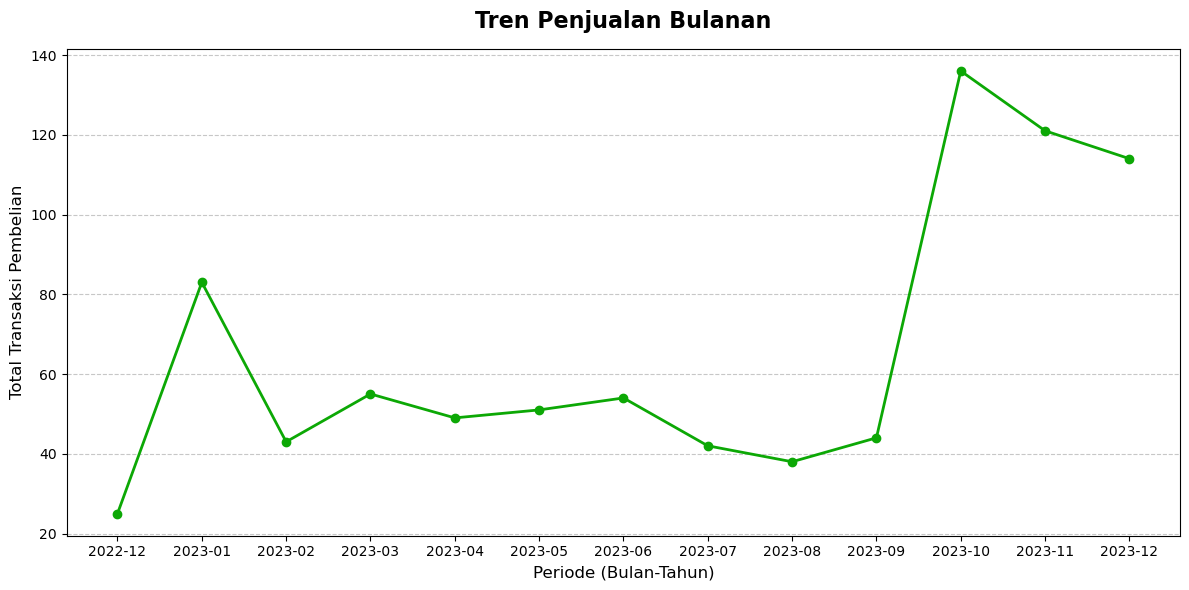

In [28]:
# pembuatan grafik tren penjualan per bulan
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales['Month-Year'], monthly_sales['Total Sales'], marker='o', linestyle='-', color='#0CA805', linewidth=2)
plt.title('Tren Penjualan Bulanan', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Periode (Bulan-Tahun)', fontsize=12)
plt.ylabel('Total Transaksi Pembelian', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()
